In [20]:
import json
import torch
import numpy as np
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# -----------------------------
# CONFIG
# -----------------------------
EPOCHS      = 30
LEARNING_RATE = 1e-3
PATIENCE    = 10
GRAD_CLIP   = 1.0
EMBED_DIM   = 64
HIDDEN_DIM  = 128
MAX_LEN     = 200
BATCH_SIZE  = 64

In [21]:
def load_json(path):
    with open(path, "r") as f:
        data = json.load(f)

    texts = []
    labels = []

    for r in data:
        req = r["request"]

        method = req.get("method", "")
        url = req.get("url", "")
        body = req.get("body", "")
        tag = req.get("Attack_Tag", "Normal")

        text = method + " " + url + " " + body

        label = 0 if tag == "Normal" else 1

        texts.append(text)
        labels.append(label)

    return texts, labels



In [22]:
print("Loading datasets...")

t1, l1 = load_json("/kaggle/input/datasets/keertishekhawat/abi-abuse-detection-using-lstm/dataset_1_train/dataset_1_train.json")
t2, l2 = load_json("/kaggle/input/datasets/keertishekhawat/abi-abuse-detection-using-lstm/dataset_2_train/dataset_2_train.json")

train_texts = t1 + t2
train_labels = l1 + l2

val_texts, val_labels = load_json("/kaggle/input/datasets/keertishekhawat/abi-abuse-detection-using-lstm/dataset_3_train/dataset_3_train.json")

test_texts, test_labels = load_json("/kaggle/input/datasets/keertishekhawat/abi-abuse-detection-using-lstm/dataset_3_val/dataset_3_val.json")

ft_texts, ft_labels = load_json("/kaggle/input/datasets/keertishekhawat/abi-abuse-detection-using-lstm/dataset_4_train/dataset_4_train.json")

ft_val_texts, ft_val_labels = load_json("/kaggle/input/datasets/keertishekhawat/abi-abuse-detection-using-lstm/dataset_4_val/dataset_4_val.json")


def print_stats(name, labels):
    c = Counter(labels)
    print(name, "Normal:", c[0], "Attack:", c[1])


print_stats("Train", train_labels)
print_stats("Validation", val_labels)
print_stats("Test", test_labels)
print_stats("Finetune Train", ft_labels)
print_stats("Finetune Val", ft_val_labels)


Loading datasets...
Train Normal: 119932 Attack: 11850
Validation Normal: 128384 Attack: 16116
Test Normal: 25500 Attack: 0
Finetune Train Normal: 143431 Attack: 39336
Finetune Val Normal: 32253 Attack: 0


In [23]:
def build_vocab(texts):
    chars = set()

    for t in texts:
        for c in t:
            chars.add(c)

    vocab = {"<pad>": 0}

    for i, c in enumerate(sorted(chars), start=1):
        vocab[c] = i

    return vocab


def encode(text, vocab):
    ids = []

    for c in text[:MAX_LEN]:
        ids.append(vocab.get(c, 0))

    if len(ids) < MAX_LEN:
        ids += [0] * (MAX_LEN - len(ids))

    return ids


def encode_dataset(texts, vocab):
    return [encode(t, vocab) for t in texts]


print("Building vocabulary...")
vocab = build_vocab(train_texts)

train_x = encode_dataset(train_texts, vocab)
val_x = encode_dataset(val_texts, vocab)
test_x = encode_dataset(test_texts, vocab)

ft_x = encode_dataset(ft_texts, vocab)
ft_val_x = encode_dataset(ft_val_texts, vocab)

Building vocabulary...


In [24]:
class APIDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x)
        self.y = torch.tensor(y).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


train_loader = DataLoader(APIDataset(train_x, train_labels), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(APIDataset(val_x, val_labels), batch_size=BATCH_SIZE)

test_loader = DataLoader(APIDataset(test_x, test_labels), batch_size=BATCH_SIZE)

ft_loader = DataLoader(APIDataset(ft_x, ft_labels), batch_size=BATCH_SIZE, shuffle=True)
ft_val_loader = DataLoader(APIDataset(ft_val_x, ft_val_labels), batch_size=BATCH_SIZE)

In [25]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=0)
        self.lstm = nn.LSTM(
            EMBED_DIM, HIDDEN_DIM,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True        # ✅ IMPROVEMENT: reads sequence both ways
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(HIDDEN_DIM * 2, 1)   # *2 because bidirectional

    def forward(self, x):
        x = self.embed(x)
        _, (h, _) = self.lstm(x)
        # concat last forward + backward hidden state
        h = torch.cat([h[-2], h[-1]], dim=1)
        h = self.dropout(h)
        return self.fc(h).squeeze(-1)   # ✅ raw logits, NO sigmoid here

model = LSTMModel(len(vocab)).to(DEVICE)

In [26]:
pos = sum(train_labels)
neg = len(train_labels) - pos
pos_weight = torch.tensor([neg / pos]).to(DEVICE)
print(f"Class balance — Pos: {pos} | Neg: {neg} | pos_weight: {pos_weight.item():.2f}")

Class balance — Pos: 11850 | Neg: 119932 | pos_weight: 10.12


In [27]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # ✅ handles imbalance
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

In [28]:
def evaluate(loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)                        # raw logits
            probs  = torch.sigmoid(logits)           # sigmoid ONCE here
            preds.extend(probs.cpu().numpy())
            targets.extend(y.numpy())

    preds_bin = [1 if p > 0.5 else 0 for p in preds]
    return (
        accuracy_score(targets, preds_bin),
        precision_score(targets, preds_bin, zero_division=0),
        recall_score(targets, preds_bin, zero_division=0),
        f1_score(targets, preds_bin, zero_division=0),
        roc_auc_score(targets, preds)
    )


In [29]:

print("\nTraining LSTM Model...")
best_acc = 0
patience = 0
history = {"loss": [], "acc": [], "precision": [], "recall": [], "f1": [], "roc": []}

for epoch in range(EPOCHS):
    acc, precision, recall, f1, roc = evaluate(val_loader)

    # ✅ ADD THIS after evaluate()
    history["loss"].append(avg_loss)
    history["acc"].append(acc)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["f1"].append(f1)
    history["roc"].append(roc)
    
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.float().to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)                            # raw logits, shape (batch,)
        loss   = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    acc, precision, recall, f1, roc = evaluate(val_loader)
    scheduler.step(f1)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.4f} | "
        f"Acc: {acc*100:.2f}% | Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | F1: {f1:.3f} | ROC-AUC: {roc:.3f}"
    )

    if acc > best_acc:
        best_acc = acc
        patience = 0
        torch.save(model.state_dict(), "lstm_best.pt")
        print("✅ New best model saved -> lstm_best.pt")
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"\n⛔ Early stopping | Best val acc: {best_acc:.3f}")
            break


Training LSTM Model...
Epoch [1/30] | Loss: 1.1786 | Acc: 65.33% | Precision: 0.108 | Recall: 0.289 | F1: 0.157 | ROC-AUC: 0.513
✅ New best model saved -> lstm_best.pt
Epoch [2/30] | Loss: 1.1901 | Acc: 86.36% | Precision: 0.237 | Recall: 0.100 | F1: 0.141 | ROC-AUC: 0.528
✅ New best model saved -> lstm_best.pt
Epoch [3/30] | Loss: 1.1592 | Acc: 86.11% | Precision: 0.225 | Recall: 0.100 | F1: 0.139 | ROC-AUC: 0.528
Epoch [4/30] | Loss: 1.1772 | Acc: 78.20% | Precision: 0.116 | Recall: 0.144 | F1: 0.128 | ROC-AUC: 0.516
Epoch [5/30] | Loss: 1.1115 | Acc: 85.41% | Precision: 0.229 | Recall: 0.130 | F1: 0.166 | ROC-AUC: 0.539
Epoch [6/30] | Loss: 1.1389 | Acc: 85.46% | Precision: 0.217 | Recall: 0.117 | F1: 0.152 | ROC-AUC: 0.532
Epoch [7/30] | Loss: 1.1125 | Acc: 83.76% | Precision: 0.195 | Recall: 0.146 | F1: 0.167 | ROC-AUC: 0.537
Epoch [8/30] | Loss: 1.1775 | Acc: 85.91% | Precision: 0.216 | Recall: 0.101 | F1: 0.137 | ROC-AUC: 0.523
Epoch [9/30] | Loss: 1.1389 | Acc: 54.01% | Precis

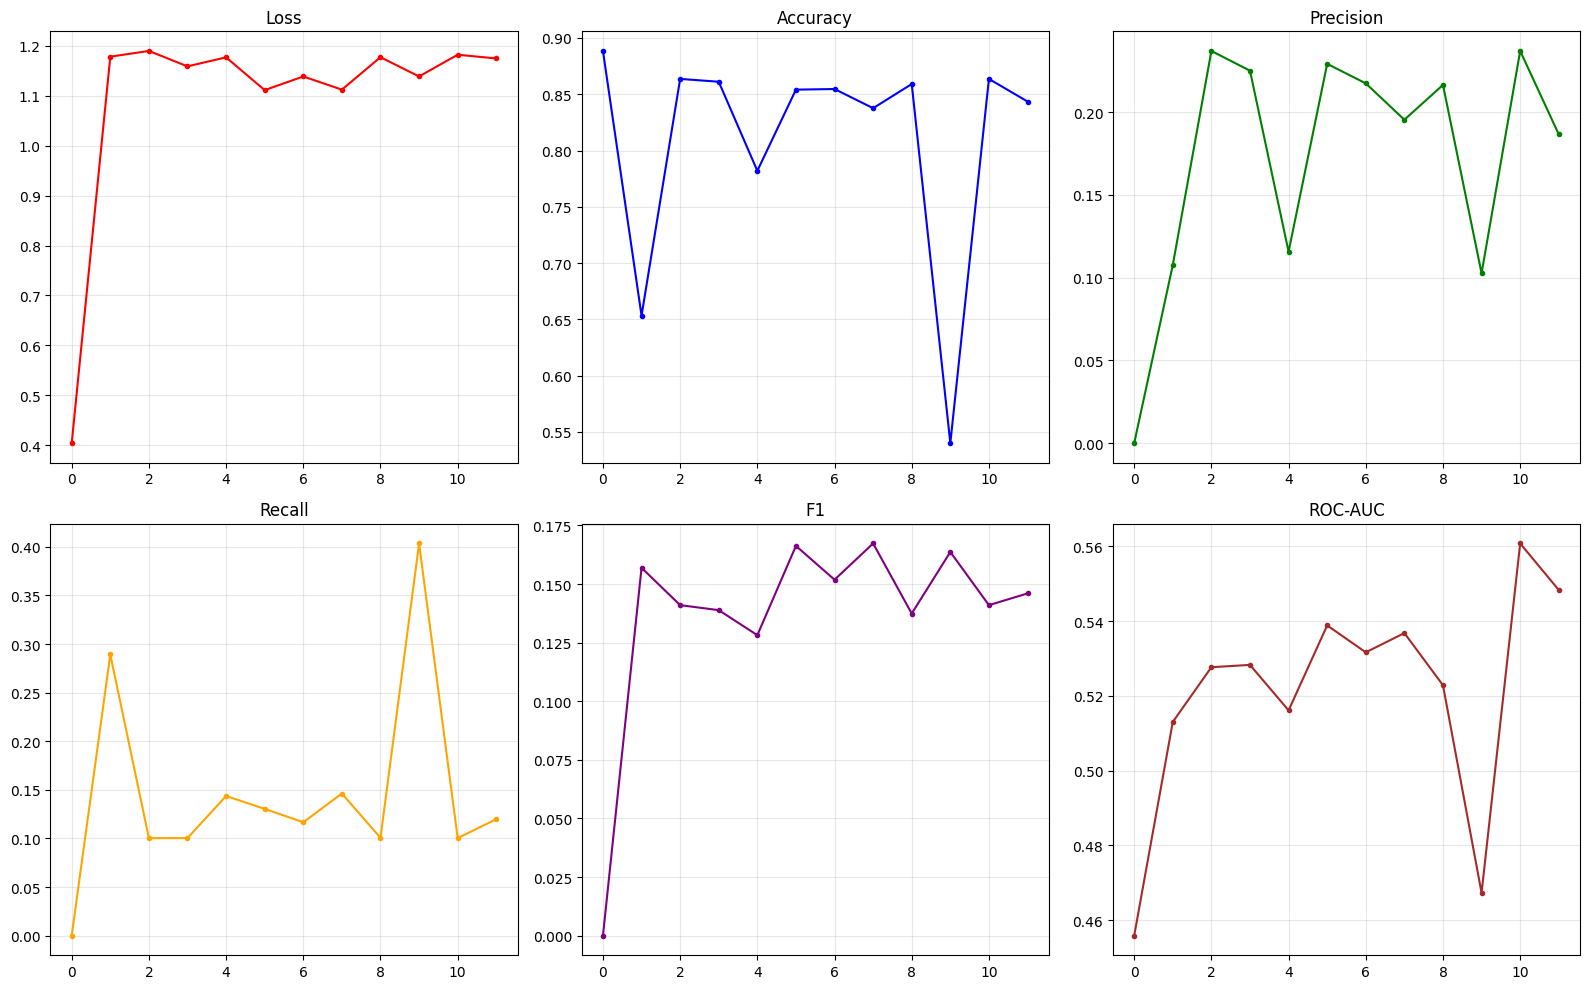

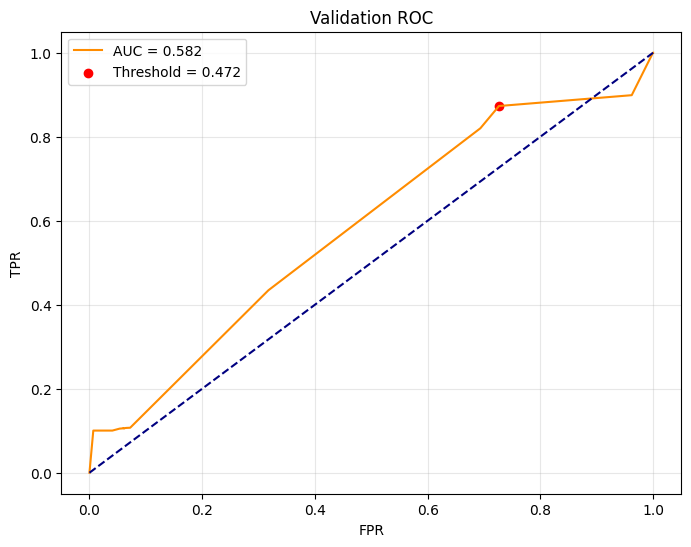

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


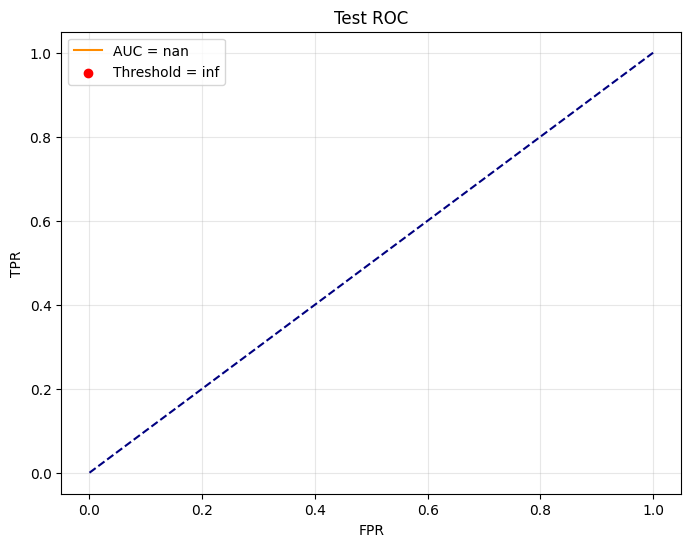

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# -- call after training --
def plot_history(history):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for ax, (key, title, color) in zip(axes.flat, [
        ("loss", "Loss", "red"), ("acc", "Accuracy", "blue"),
        ("precision", "Precision", "green"), ("recall", "Recall", "orange"),
        ("f1", "F1", "purple"), ("roc", "ROC-AUC", "brown")
    ]):
        ax.plot(history[key], color=color, marker="o", markersize=3)
        ax.set_title(title); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("training_history.png")
    plt.show()

def plot_roc(loader, title="ROC Curve"):
    model.eval()
    probs, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            probs.extend(torch.sigmoid(model(x.to(DEVICE))).cpu().numpy())
            targets.extend(y.numpy())
    fpr, tpr, thresh = roc_curve(targets, probs)
    roc_auc = auc(fpr, tpr)
    best = (tpr - fpr).argmax()
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], "--", color="navy")
    plt.scatter(fpr[best], tpr[best], color="red", label=f"Threshold = {thresh[best]:.3f}")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(title)
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig("roc_curve.png")
    plt.show()

plot_history(history)
plot_roc(val_loader, "Validation ROC")
plot_roc(test_loader, "Test ROC")

In [31]:
print("\nFine-tuning on dataset 4...")
model.load_state_dict(torch.load("lstm_best.pt"))

# lower LR so pretrained weights aren't destroyed
ft_optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
best_ft_acc = 0

for epoch in range(10):
    model.train()
    total_loss = 0
    for x, y in ft_loader:
        x, y = x.to(DEVICE), y.float().to(DEVICE)
        ft_optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        ft_optimizer.step()
        total_loss += loss.item()

    acc, precision, recall, f1, roc = evaluate(ft_val_loader)
    print(f"FT Epoch [{epoch+1}/10] | Loss: {total_loss/len(ft_loader):.4f} | Acc: {acc*100:.2f}% | F1: {f1:.3f}")

    if acc > best_ft_acc:
        best_ft_acc = acc
        torch.save(model.state_dict(), "lstm_finetuned.pt")
        print(f"✅ Best model saved | Acc: {best_ft_acc*100:.2f}%")

print(f"\n🏁 Done | Best Acc: {best_ft_acc*100:.2f}%")


Fine-tuning on dataset 4...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


FT Epoch [1/10] | Loss: 1.7321 | Acc: 0.00% | F1: 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


FT Epoch [2/10] | Loss: 1.7030 | Acc: 0.00% | F1: 0.000


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


FT Epoch [8/10] | Loss: 0.8628 | Acc: 78.37% | F1: 0.000
✅ Best model saved | Acc: 78.37%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


FT Epoch [9/10] | Loss: 0.5322 | Acc: 80.02% | F1: 0.000
✅ Best model saved | Acc: 80.02%
FT Epoch [10/10] | Loss: 0.4860 | Acc: 80.46% | F1: 0.000
✅ Best model saved | Acc: 80.46%

🏁 Done | Best Acc: 80.46%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [32]:
# -----------------------------
# TEST EVALUATION
# -----------------------------

def test_model(path):

    model.load_state_dict(torch.load(path))

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for x, y in test_loader:

            x = x.to(DEVICE)

            out = model(x).cpu()

            preds += list(out.numpy())
            targets += list(y.numpy())

    preds_bin = [1 if p > 0.5 else 0 for p in preds]

    p = precision_score(targets, preds_bin)
    r = recall_score(targets, preds_bin)
    f = f1_score(targets, preds_bin)
    roc = roc_auc_score(targets, preds)

    cm = confusion_matrix(targets, preds_bin)

    return p, r, f, roc, cm


print("\nEvaluating Base Model")
p, r, f, roc, cm = test_model("lstm_best.pt")

print("Precision:", p)
print("Recall:", r)
print("F1:", f)
print("ROC-AUC:", roc)
print("Confusion Matrix\n", cm)


print("\nEvaluating Fine-tuned Model")
p, r, f, roc, cm = test_model("lstm_finetuned.pt")

print("Precision:", p)
print("Recall:", r)
print("F1:", f)
print("ROC-AUC:", roc)
print("Confusion Matrix\n", cm)


Evaluating Base Model


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: nan
Confusion Matrix
 [[24316  1184]
 [    0     0]]

Evaluating Fine-tuned Model
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: nan
Confusion Matrix
 [[22906  2594]
 [    0     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [33]:
print("Train size:", len(train_loader.dataset))
print("Val size:", len(val_loader.dataset))



Train size: 131782
Val size: 144500


In [34]:
import numpy as np

train_labels = []
for _, y in train_loader:
    train_labels.extend(y.numpy())

val_labels = []
for _, y in val_loader:
    val_labels.extend(y.numpy())

print("Train Normal:", np.sum(np.array(train_labels) == 0))
print("Train Attack:", np.sum(np.array(train_labels) == 1))

print("Val Normal:", np.sum(np.array(val_labels) == 0))
print("Val Attack:", np.sum(np.array(val_labels) == 1))

Train Normal: 119932
Train Attack: 11850
Val Normal: 128384
Val Attack: 16116
